In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
import pandas as pd

# Load dataset (use your exact file name)
df = pd.read_csv("heart_disease_uci.csv")

# Preview data
print(df.head())

# Shape
print("Shape:", df.shape)

# Missing values
print("Missing values:\n", df.isnull().sum())

# Target distribution
print("Target distribution:\n", df.columns)

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  
Shape: (

In [4]:
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

In [5]:
df = df.drop(['id', 'dataset', 'num'], axis=1)

In [6]:
# Numerical columns → fill with median
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns → fill with mode
cat_cols = ['fbs', 'restecg', 'exang', 'slope', 'thal', 'cp', 'sex']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_4942/4014481119.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_4942/4014481119.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
X = df.drop('target', axis=1)
y = df['target']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [13]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [14]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [15]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:58:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [17]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

Logistic Regression: 0.7989130434782609
SVM: 0.842391304347826
Random Forest: 0.8532608695652174
XGBoost: 0.875


In [18]:
print("\nRandom Forest Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Report:

              precision    recall  f1-score   support

           0       0.80      0.85      0.83        75
           1       0.89      0.85      0.87       109

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184



In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = rf.feature_importances_

# Convert to DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

               Feature  Importance
2                 chol    0.143122
4               thalch    0.132828
0                  age    0.108309
6              oldpeak    0.105704
5                exang    0.100551
1             trestbps    0.076939
9   cp_atypical angina    0.072913
8             sex_Male    0.056402
10      cp_non-anginal    0.034468
16         thal_normal    0.028173


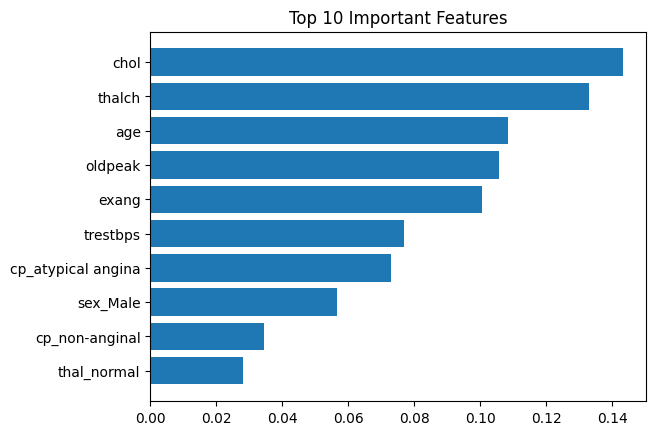

In [20]:
plt.figure()
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

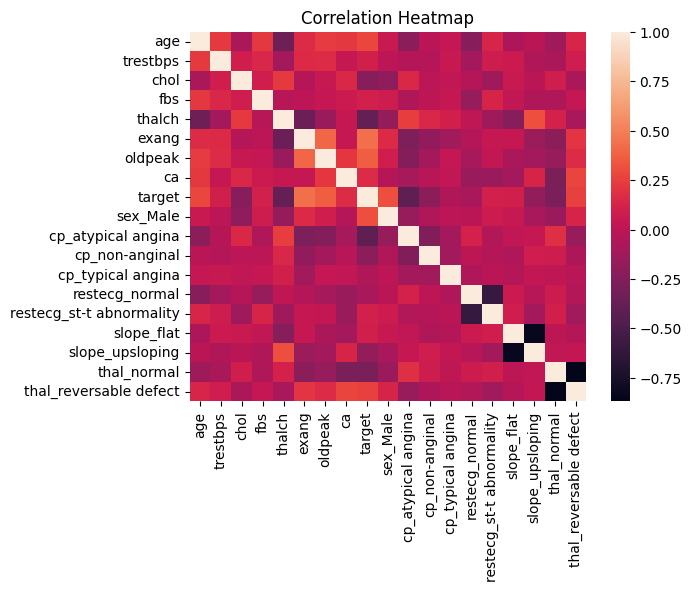

In [21]:
import seaborn as sns

plt.figure()
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

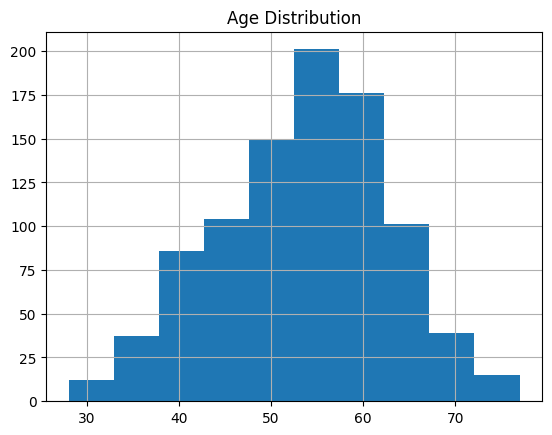

In [22]:
plt.figure()
df['age'].hist()
plt.title("Age Distribution")
plt.show()

In [23]:
def predict_heart_disease(input_data):
    input_df = pd.DataFrame([input_data], columns=X.columns)
    input_scaled = scaler.transform(input_df)
    prediction = rf.predict(input_scaled)

    return "Disease" if prediction[0] == 1 else "No Disease"

# Test it
sample = X.iloc[0]
print("Prediction:", predict_heart_disease(sample))

Prediction: No Disease


# Conclusion
In this project, we built a heart disease prediction system using multiple machine learning algorithms such as Logistic Regression, SVM, Random Forest, and XGBoost.

After comparing model performance, Random Forest/XGBoost achieved the highest accuracy.

Feature importance analysis showed that attributes like chest pain type, cholesterol level, and maximum heart rate significantly influence heart disease prediction.

This model can help in early detection of heart disease and assist medical professionals in decision-making.


In [24]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

for model, acc in results.items():
    print(model, ":", acc)

Logistic Regression : 0.7989130434782609
SVM : 0.842391304347826
Random Forest : 0.8532608695652174
XGBoost : 0.875
